In [1]:
import pandas as pd
import numpy as np
import time
import json
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

os.makedirs('../results', exist_ok=True)

LABEL_MAP = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index()}")
print(f"\nClass distribution (test):\n{y_test.value_counts().sort_index()}")

X_train: (1062114, 30)
X_test:  (265529, 30)

Class distribution (train):
Label_encoded
0    318298
1    239759
2    239095
3    139403
4    125559
Name: count, dtype: int64

Class distribution (test):
Label_encoded
0    79574
1    59940
2    59774
3    34851
4    31390
Name: count, dtype: int64


In [3]:
# Stage 1 binary labels
y_train_binary = y_train.apply(lambda x: 'Benign' if x == 0 else 'Attack')
y_test_binary  = y_test.apply(lambda x: 'Benign' if x == 0 else 'Attack')

le_binary = LabelEncoder()
y_train_binary_enc = le_binary.fit_transform(y_train_binary)
y_test_binary_enc  = le_binary.transform(y_test_binary)
print(f"Binary label encoding: {dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_)))}")

# Stage 2 attack-only rows
attack_mask_train = y_train != 0
attack_mask_test  = y_test != 0
X_train_attack = X_train[attack_mask_train]
y_train_attack = y_train[attack_mask_train]
X_test_attack  = X_test[attack_mask_test]
y_test_attack  = y_test[attack_mask_test]

le_attack = LabelEncoder()
y_train_attack_enc = le_attack.fit_transform(y_train_attack)
y_test_attack_enc  = le_attack.transform(y_test_attack)
print(f"Attack label encoding: {dict(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)))}")

print(f"\nX_train_attack: {X_train_attack.shape}")
print(f"X_test_attack:  {X_test_attack.shape}")

Binary label encoding: {'Attack': np.int64(0), 'Benign': np.int64(1)}
Attack label encoding: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}

X_train_attack: (743816, 30)
X_test_attack:  (185955, 30)


In [4]:
stage1_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'ET':   ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'HGB':  HistGradientBoostingClassifier(random_state=42)   # fast gradient boosting
}

stage1_results = {}
stage1_preds   = {}
stage1_fitted  = {}

for name, model in stage1_models.items():
    print(f"\n--- Stage 1: {name} ---")
    t0 = time.time()
    model.fit(X_train, y_train_binary_enc)
    train_time = time.time() - t0
    stage1_fitted[name] = model

    y_pred_enc = model.predict(X_test)
    y_pred     = le_binary.inverse_transform(y_pred_enc)
    stage1_preds[name] = y_pred

    # train accuracy for overfitting check
    y_train_pred_enc = model.predict(X_train)
    train_acc = accuracy_score(y_train_binary_enc, y_train_pred_enc)

    acc  = accuracy_score(y_test_binary, y_pred)
    prec = precision_score(y_test_binary, y_pred, pos_label='Attack')
    rec  = recall_score(y_test_binary, y_pred, pos_label='Attack')
    f1   = f1_score(y_test_binary, y_pred, pos_label='Attack')

    cm  = confusion_matrix(y_test_binary, y_pred, labels=['Benign', 'Attack'])
    fn  = cm[1][0]
    total_attacks = cm[1][0] + cm[1][1]
    fnr = fn / total_attacks if total_attacks > 0 else 0

    stage1_results[name] = {
        'train_accuracy': train_acc,
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'confusion_matrix': cm.tolist(), 'false_negative_rate': fnr,
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit gap: {train_acc - acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")
    print(f"Train time: {train_time:.1f}s")
    print(f"Confusion Matrix [Benign, Attack]:\n{cm}")


--- Stage 1: DT ---
Train Acc: 0.9958 | Test Acc: 0.8928 | Overfit gap: 0.1031
Precision: 0.9220 | Recall: 0.9251 | F1: 0.9236 | FNR: 0.0749
Train time: 15.5s
Confusion Matrix [Benign, Attack]:
[[ 65025  14549]
 [ 13924 172031]]

--- Stage 1: RF ---
Train Acc: 0.9958 | Test Acc: 0.9050 | Overfit gap: 0.0908
Precision: 0.9378 | Recall: 0.9257 | F1: 0.9317 | FNR: 0.0743
Train time: 51.5s
Confusion Matrix [Benign, Attack]:
[[ 68165  11409]
 [ 13815 172140]]

--- Stage 1: XGB ---
Train Acc: 0.9096 | Test Acc: 0.9088 | Overfit gap: 0.0009
Precision: 0.9539 | Recall: 0.9140 | F1: 0.9335 | FNR: 0.0860
Train time: 2.4s
Confusion Matrix [Benign, Attack]:
[[ 71354   8220]
 [ 16001 169954]]

--- Stage 1: LGBM ---
Train Acc: 0.8983 | Test Acc: 0.8985 | Overfit gap: -0.0002
Precision: 0.9442 | Recall: 0.9088 | F1: 0.9262 | FNR: 0.0912
Train time: 2.7s
Confusion Matrix [Benign, Attack]:
[[ 69586   9988]
 [ 16958 168997]]

--- Stage 1: ET ---
Train Acc: 0.9958 | Test Acc: 0.9030 | Overfit gap: 0.092

In [5]:
stage2_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'ET':   ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'HGB':  HistGradientBoostingClassifier(random_state=42)
}

stage2_results = {}
stage2_preds   = {}
stage2_fitted  = {}

for name, model in stage2_models.items():
    print(f"\n--- Stage 2: {name} ---")
    t0 = time.time()
    model.fit(X_train_attack, y_train_attack_enc)
    train_time = time.time() - t0
    stage2_fitted[name] = model

    y_pred_enc = model.predict(X_test_attack)
    y_pred     = le_attack.inverse_transform(y_pred_enc)
    stage2_preds[name] = y_pred

    # train accuracy for overfitting check
    y_train_pred_enc = model.predict(X_train_attack)
    train_acc = accuracy_score(y_train_attack_enc, y_train_pred_enc)

    acc  = accuracy_score(y_test_attack, y_pred)
    prec = precision_score(y_test_attack, y_pred, average='macro')
    rec  = recall_score(y_test_attack, y_pred, average='macro')
    f1   = f1_score(y_test_attack, y_pred, average='macro')

    labels_present = sorted(y_test_attack.unique())
    cm = confusion_matrix(y_test_attack, y_pred, labels=labels_present)

    stage2_results[name] = {
        'train_accuracy': train_acc,
        'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec, 'f1_macro': f1,
        'confusion_matrix': cm.tolist(),
        'labels': [LABEL_MAP[l] for l in labels_present],
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit gap: {train_acc - acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1(macro): {f1:.4f}")
    print(f"Train time: {train_time:.1f}s")
    print(classification_report(y_test_attack, y_pred,
                                 target_names=[LABEL_MAP[l] for l in labels_present]))


--- Stage 2: DT ---
Train Acc: 0.9953 | Test Acc: 0.8654 | Overfit gap: 0.1299
Precision: 0.8453 | Recall: 0.8446 | F1(macro): 0.8449
Train time: 10.8s
              precision    recall  f1-score   support

         DoS       0.88      0.88      0.88     59940
        DDoS       0.96      0.96      0.96     59774
       Mirai       0.74      0.74      0.74     34851
    Spoofing       0.80      0.80      0.80     31390

    accuracy                           0.87    185955
   macro avg       0.85      0.84      0.84    185955
weighted avg       0.87      0.87      0.87    185955


--- Stage 2: RF ---
Train Acc: 0.9952 | Test Acc: 0.8830 | Overfit gap: 0.1122
Precision: 0.8643 | Recall: 0.8698 | F1(macro): 0.8667
Train time: 34.1s
              precision    recall  f1-score   support

         DoS       0.91      0.88      0.89     59940
        DDoS       0.97      0.96      0.96     59774
       Mirai       0.76      0.81      0.78     34851
    Spoofing       0.82      0.84      0.8

In [6]:
hierarchical_results = {}
hierarchical_preds   = {}

for name in stage1_models.keys():
    print(f"\n=== Hierarchical {name} ===")

    stage1_pred = stage1_preds[name]
    stage2_model = stage2_fitted[name]

    final_pred = np.empty(len(y_test), dtype=object)

    benign_idx = np.where(stage1_pred == 'Benign')[0]
    attack_idx = np.where(stage1_pred == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_pred_enc = stage2_model.predict(X_test.iloc[attack_idx])
        s2_pred     = le_attack.inverse_transform(s2_pred_enc)
        final_pred[attack_idx] = s2_pred

    final_pred  = final_pred.astype(int)
    hierarchical_preds[name] = final_pred
    y_test_arr  = y_test.values
    all_labels  = sorted(LABEL_MAP.keys())

    acc         = accuracy_score(y_test_arr, final_pred)
    prec_macro  = precision_score(y_test_arr, final_pred, average='macro')
    rec_macro   = recall_score(y_test_arr, final_pred, average='macro')
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    cm          = confusion_matrix(y_test_arr, final_pred, labels=all_labels)
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    hierarchical_results[name] = {
        'accuracy': acc, 'precision_macro': prec_macro,
        'recall_macro': rec_macro, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'confusion_matrix': cm.tolist(),
        'labels': [LABEL_MAP[l] for l in all_labels],
        'false_negative_rate': fnr
    }

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | FNR: {fnr:.4f}")
    print(f"5-class Confusion Matrix:\n{cm}")
    print(classification_report(y_test_arr, final_pred,
                                 target_names=[LABEL_MAP[l] for l in all_labels]))


=== Hierarchical DT ===
Accuracy: 0.8172 | Macro F1: 0.7876 | Weighted F1: 0.8172 | FNR: 0.0749
5-class Confusion Matrix:
[[65025  2677   399  4112  7361]
 [ 2495 51459  1117  3872   997]
 [  381  1183 57046   580   584]
 [ 3861  4019   605 23728  2638]
 [ 7187  1165   574  2733 19731]]
              precision    recall  f1-score   support

      Benign       0.82      0.82      0.82     79574
         DoS       0.85      0.86      0.85     59940
        DDoS       0.95      0.95      0.95     59774
       Mirai       0.68      0.68      0.68     34851
    Spoofing       0.63      0.63      0.63     31390

    accuracy                           0.82    265529
   macro avg       0.79      0.79      0.79    265529
weighted avg       0.82      0.82      0.82    265529


=== Hierarchical RF ===
Accuracy: 0.8398 | Macro F1: 0.8137 | Weighted F1: 0.8402 | FNR: 0.0743
5-class Confusion Matrix:
[[68165  1729   266  3820  5594]
 [ 2450 51094   921  4506   969]
 [  366  1116 57106   626   560]


In [7]:
# Based on best performing new results
# Now with 6 models we can also try ET which may surprise us
cross_combos = [
    ('RF',  'XGB'),   # best FNR at S1 + best F1 at S2
    ('ET',  'XGB'),   # close second FNR + best F1 at S2
    ('RF',  'HGB'),   # best FNR + well-generalizing S2
    ('ET',  'RF'),    # both low FNR, RF edges ET on S2 F1
    ('RF',  'ET'),    # flip of above
]

cross_results = {}

for s1_name, s2_name in cross_combos:
    label = f"S1={s1_name}_S2={s2_name}"
    print(f"\n=== Cross-Model: {label} ===")

    stage1_pred  = stage1_preds[s1_name]
    stage2_model = stage2_fitted[s2_name]

    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(stage1_pred == 'Benign')[0]
    attack_idx = np.where(stage1_pred == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_pred_enc = stage2_model.predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_pred_enc)

    final_pred  = final_pred.astype(int)
    y_test_arr  = y_test.values
    all_labels  = sorted(LABEL_MAP.keys())

    acc         = accuracy_score(y_test_arr, final_pred)
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    cross_results[label] = {
        'accuracy': acc, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'false_negative_rate': fnr
    }

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f} | FNR: {fnr:.4f}")


=== Cross-Model: S1=RF_S2=XGB ===
Accuracy: 0.8411 | Macro F1: 0.8149 | FNR: 0.0743

=== Cross-Model: S1=ET_S2=XGB ===
Accuracy: 0.8393 | Macro F1: 0.8131 | FNR: 0.0751

=== Cross-Model: S1=RF_S2=HGB ===
Accuracy: 0.8382 | Macro F1: 0.8108 | FNR: 0.0743

=== Cross-Model: S1=ET_S2=RF ===
Accuracy: 0.8380 | Macro F1: 0.8119 | FNR: 0.0751

=== Cross-Model: S1=RF_S2=ET ===
Accuracy: 0.8379 | Macro F1: 0.8111 | FNR: 0.0743


In [8]:
print("=" * 65)
print("ERROR PROPAGATION ANALYSIS")
print("=" * 65)

y_test_arr = y_test.values
attack_test_mask = y_test_arr != 0

for name in stage1_models.keys():
    s1_pred   = stage1_preds[name]           # 'Benign' / 'Attack'
    s2_pred   = stage2_preds[name]           # original 1-4 labels, attack rows only
    final     = hierarchical_preds[name]

    total_errors = np.sum(final != y_test_arr)

    # Stage 1 errors: attacks predicted as Benign (false negatives — unrecoverable)
    s1_fn_mask = (y_test_arr != 0) & (s1_pred == 'Benign')
    s1_fp_mask = (y_test_arr == 0) & (s1_pred == 'Attack')   # benign routed to stage 2
    s1_fn      = s1_fn_mask.sum()
    s1_fp      = s1_fp_mask.sum()

    # Stage 2 errors: correctly routed attacks but misclassified by stage 2
    # these are attack rows where stage 1 said Attack but stage 2 got wrong label
    correctly_routed_mask = (y_test_arr != 0) & (s1_pred == 'Attack')
    s2_errors = np.sum(
        (correctly_routed_mask) & (final != y_test_arr)
    )

    # Stage 2 forced Benign errors: benign samples routed to stage 2 (always wrong)
    benign_routed_errors = s1_fp  # all of these become wrong (forced into attack label)

    theoretical_max_acc = 1 - (s1_fn + s1_fp) / len(y_test_arr)

    print(f"\n{name}:")
    print(f"  Total errors:                    {total_errors:,}  ({total_errors/len(y_test_arr)*100:.2f}%)")
    print(f"  Stage 1 false negatives (missed attacks -> Benign): {s1_fn:,}  ({s1_fn/total_errors*100:.1f}% of errors)")
    print(f"  Stage 1 false positives (Benign -> Stage 2):        {s1_fp:,}  ({s1_fp/total_errors*100:.1f}% of errors)")
    print(f"  Stage 2 misclassifications:                         {s2_errors:,}  ({s2_errors/total_errors*100:.1f}% of errors)")
    print(f"  Theoretical max accuracy (perfect Stage 2):  {theoretical_max_acc:.4f}")
    print(f"  Actual accuracy:                             {hierarchical_results[name]['accuracy']:.4f}")
    print(f"  Gap from theoretical max:                    {theoretical_max_acc - hierarchical_results[name]['accuracy']:.4f}")

ERROR PROPAGATION ANALYSIS

DT:
  Total errors:                    48,540  (18.28%)
  Stage 1 false negatives (missed attacks -> Benign): 13,924  (28.7% of errors)
  Stage 1 false positives (Benign -> Stage 2):        14,549  (30.0% of errors)
  Stage 2 misclassifications:                         20,067  (41.3% of errors)
  Theoretical max accuracy (perfect Stage 2):  0.8928
  Actual accuracy:                             0.8172
  Gap from theoretical max:                    0.0756

RF:
  Total errors:                    42,530  (16.02%)
  Stage 1 false negatives (missed attacks -> Benign): 13,815  (32.5% of errors)
  Stage 1 false positives (Benign -> Stage 2):        11,409  (26.8% of errors)
  Stage 2 misclassifications:                         17,306  (40.7% of errors)
  Theoretical max accuracy (perfect Stage 2):  0.9050
  Actual accuracy:                             0.8398
  Gap from theoretical max:                    0.0652

XGB:
  Total errors:                    40,922  (15.41

In [9]:
print("\nOVERFITTING ANALYSIS — Stage 1 (Binary)")
print(f"{'Model':<8} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 40)
for name in stage1_models.keys():
    tr = stage1_results[name]['train_accuracy']
    te = stage1_results[name]['accuracy']
    print(f"{name:<8} {tr:>10.4f} {te:>10.4f} {tr-te:>8.4f}")

print("\nOVERFITTING ANALYSIS — Stage 2 (Attack-type)")
print(f"{'Model':<8} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 40)
for name in stage2_models.keys():
    tr = stage2_results[name]['train_accuracy']
    te = stage2_results[name]['accuracy']
    print(f"{name:<8} {tr:>10.4f} {te:>10.4f} {tr-te:>8.4f}")


OVERFITTING ANALYSIS — Stage 1 (Binary)
Model     Train Acc   Test Acc      Gap
----------------------------------------
DT           0.9958     0.8928   0.1031
RF           0.9958     0.9050   0.0908
XGB          0.9096     0.9088   0.0009
LGBM         0.8983     0.8985  -0.0002
ET           0.9958     0.9030   0.0928
HGB          0.8960     0.8962  -0.0002

OVERFITTING ANALYSIS — Stage 2 (Attack-type)
Model     Train Acc   Test Acc      Gap
----------------------------------------
DT           0.9953     0.8654   0.1299
RF           0.9952     0.8830   0.1122
XGB          0.8930     0.8872   0.0058
LGBM         0.8848     0.8815   0.0033
ET           0.9953     0.8799   0.1153
HGB          0.8856     0.8820   0.0036


In [10]:
def make_json_safe(d):
    if isinstance(d, dict):   return {k: make_json_safe(v) for k, v in d.items()}
    if isinstance(d, list):   return [make_json_safe(v) for v in d]
    if isinstance(d, (np.integer,)): return int(d)
    if isinstance(d, (np.floating,)): return float(d)
    return d

all_results = {
    'stage1_binary':         make_json_safe(stage1_results),
    'stage2_attack_type':    make_json_safe(stage2_results),
    'hierarchical_combined': make_json_safe(hierarchical_results),
    'cross_model':           make_json_safe(cross_results)
}

with open('../results/experiments_hierarchical.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print("Saved to ../results/experiments_hierarchical.json")

Saved to ../results/experiments_hierarchical.json


Matplotlib is building the font cache; this may take a moment.


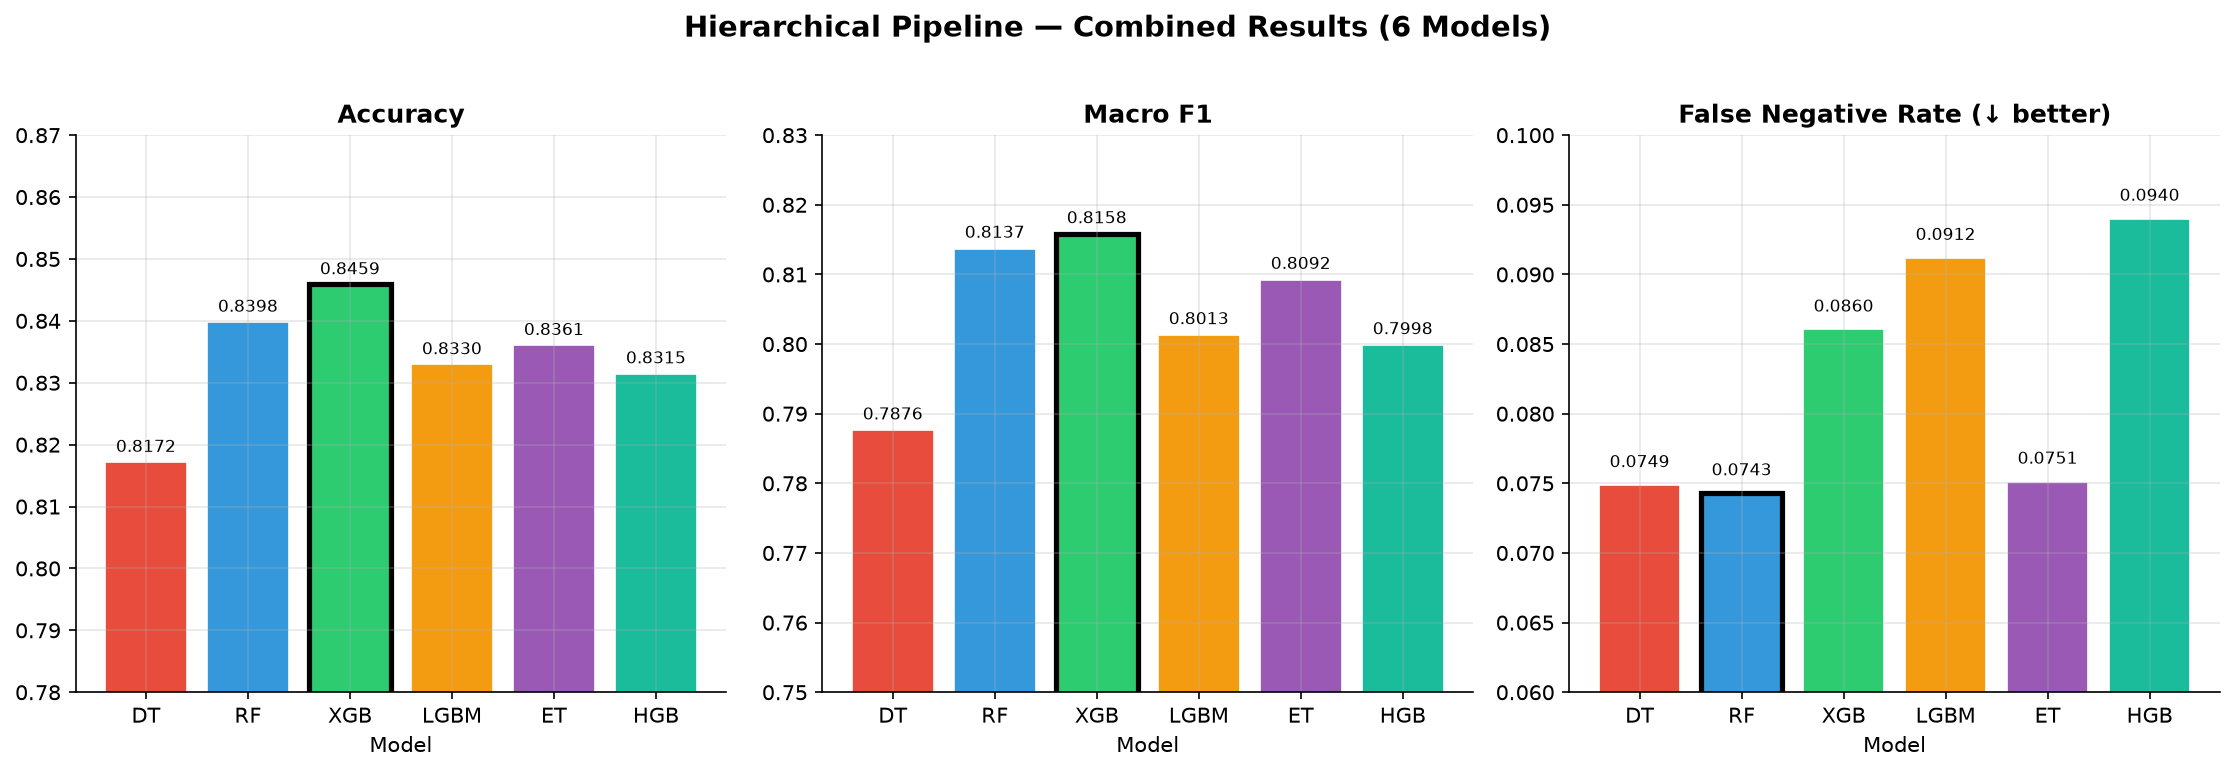

Saved: 01_combined_pipeline_comparison.png


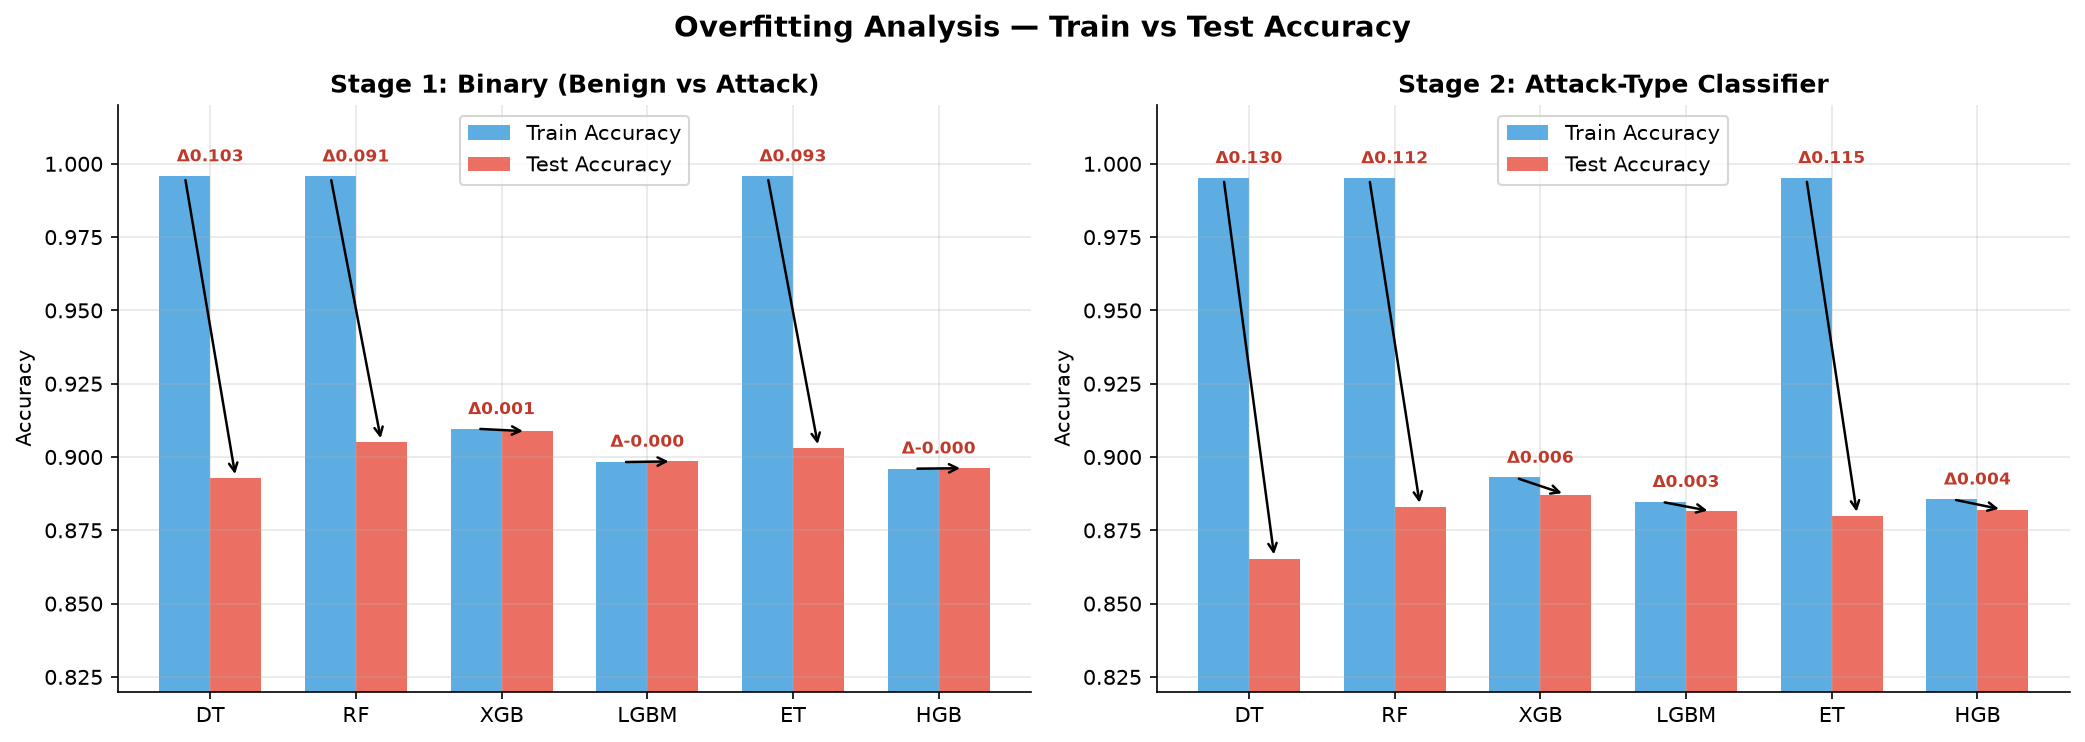

Saved: 02_overfitting_analysis.png


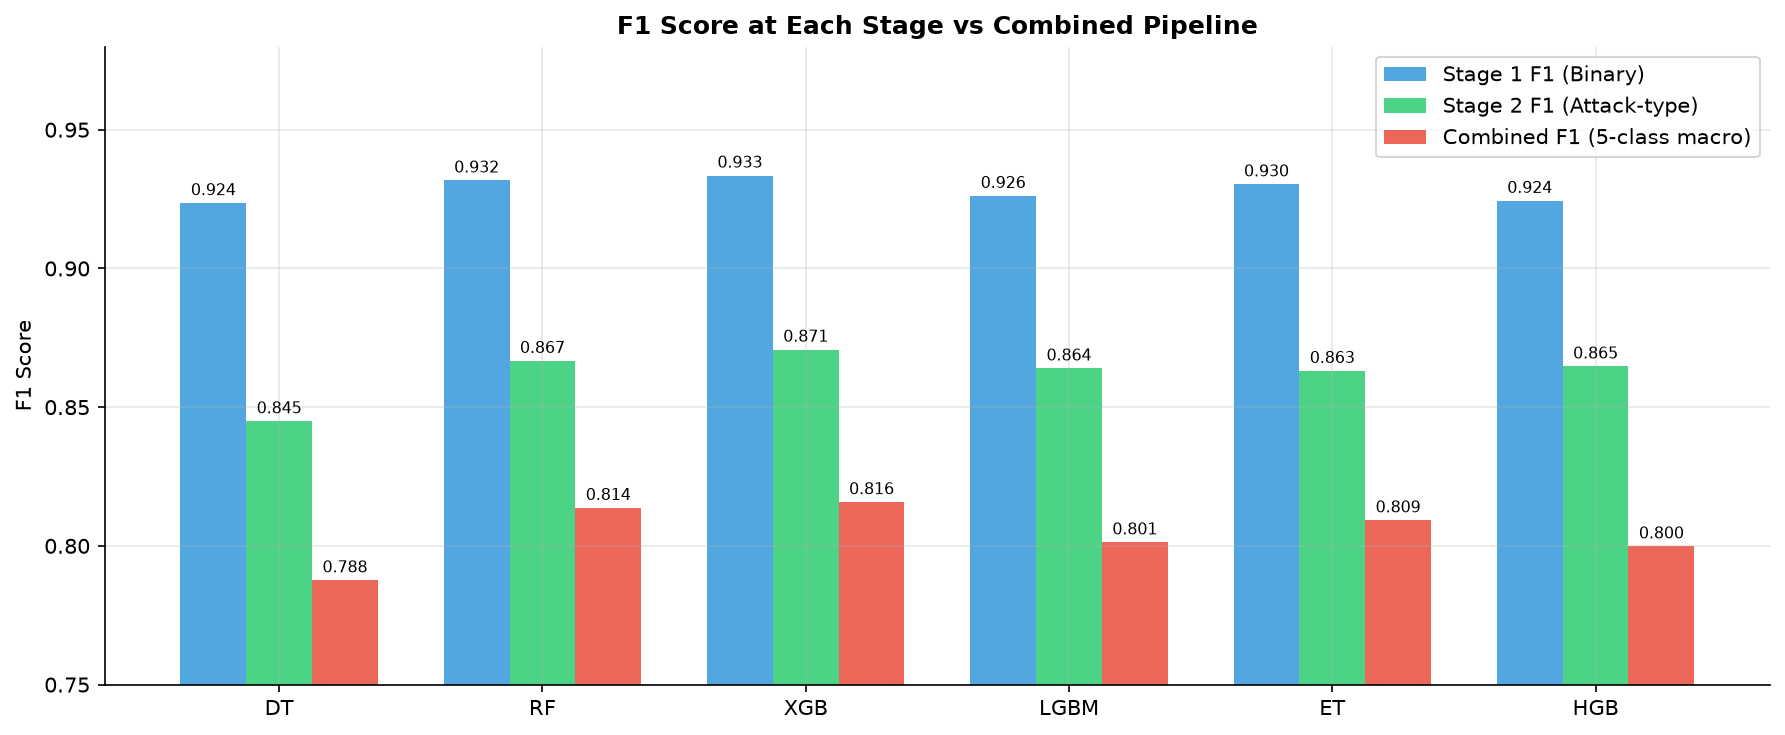

Saved: 03_stage_f1_comparison.png


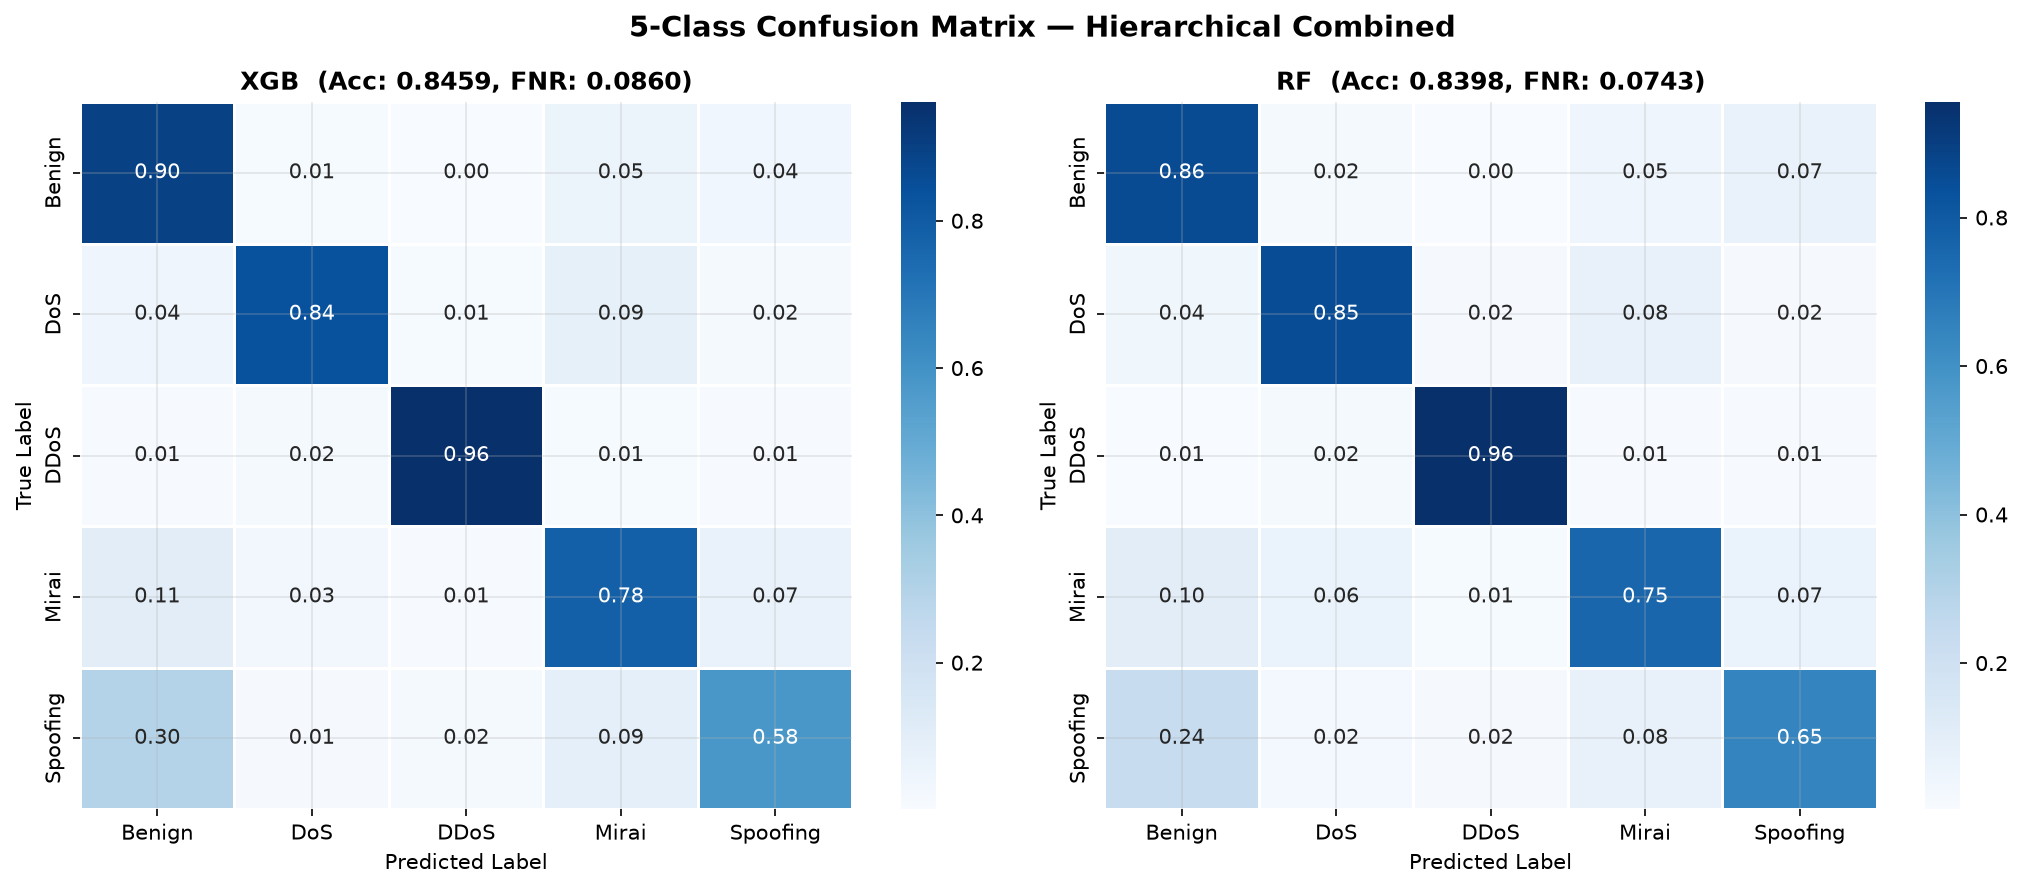

Saved: 04_confusion_matrices_xgb_rf.png


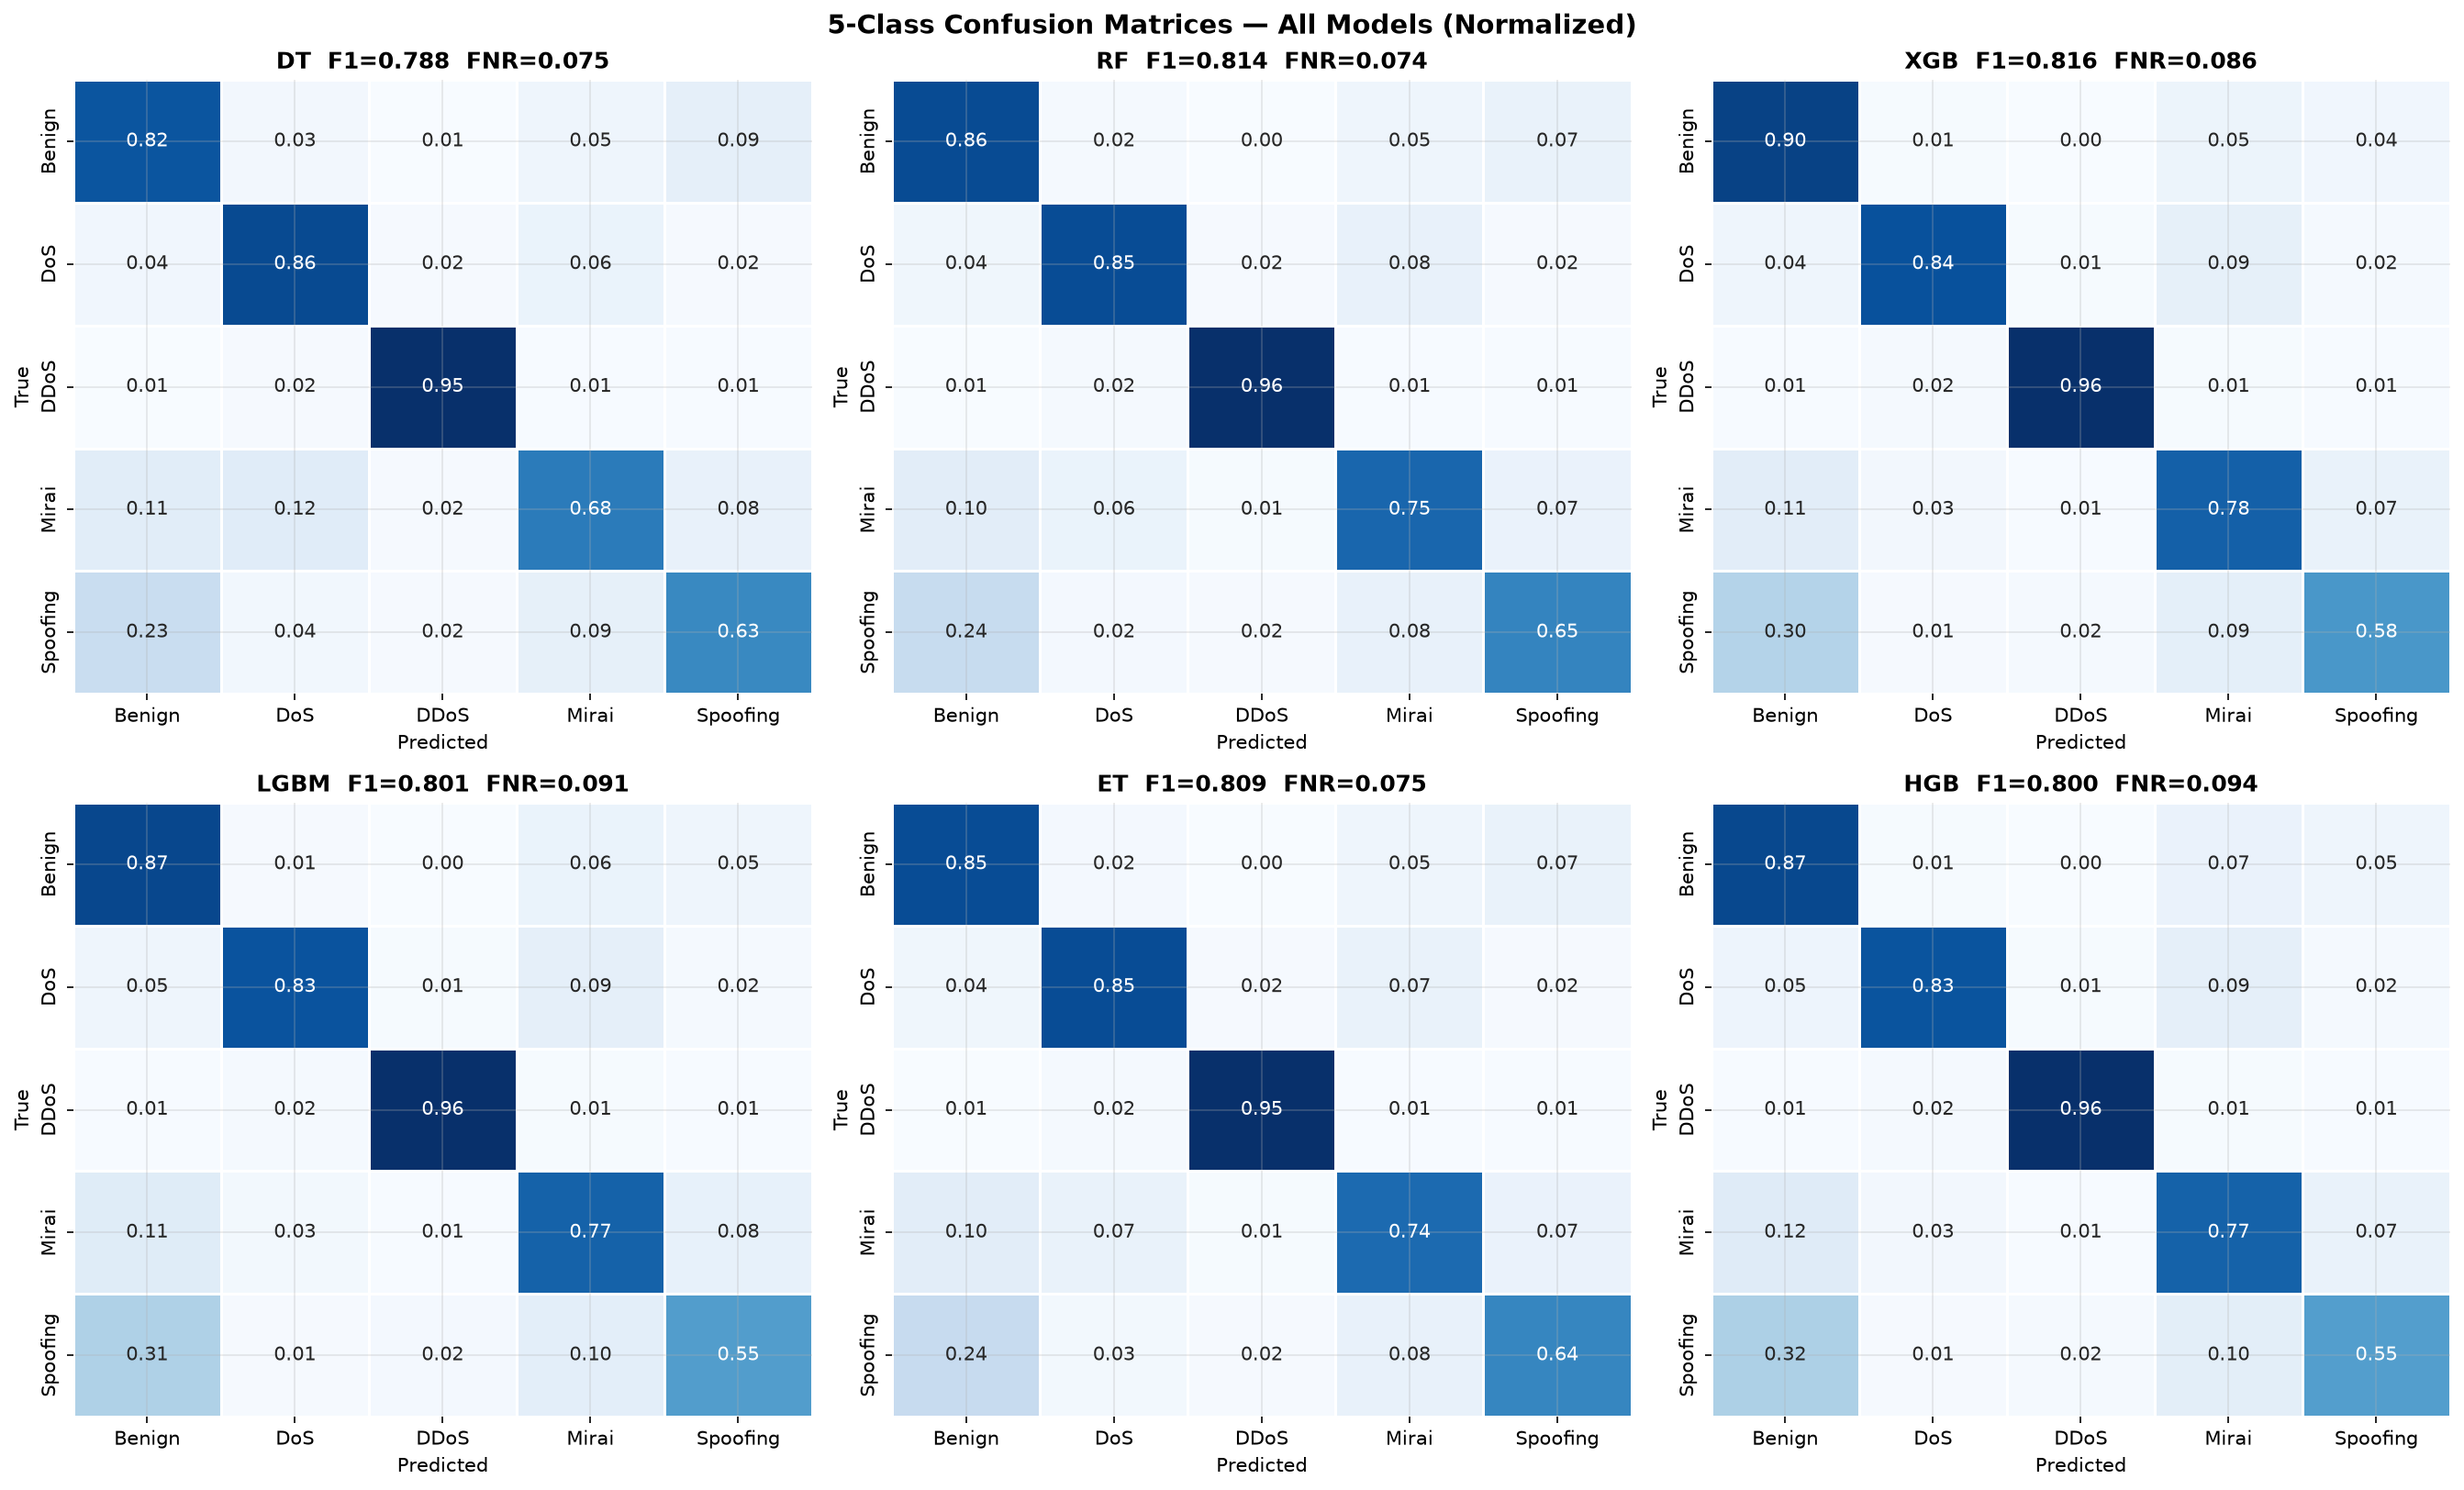

Saved: 05_all_confusion_matrices.png


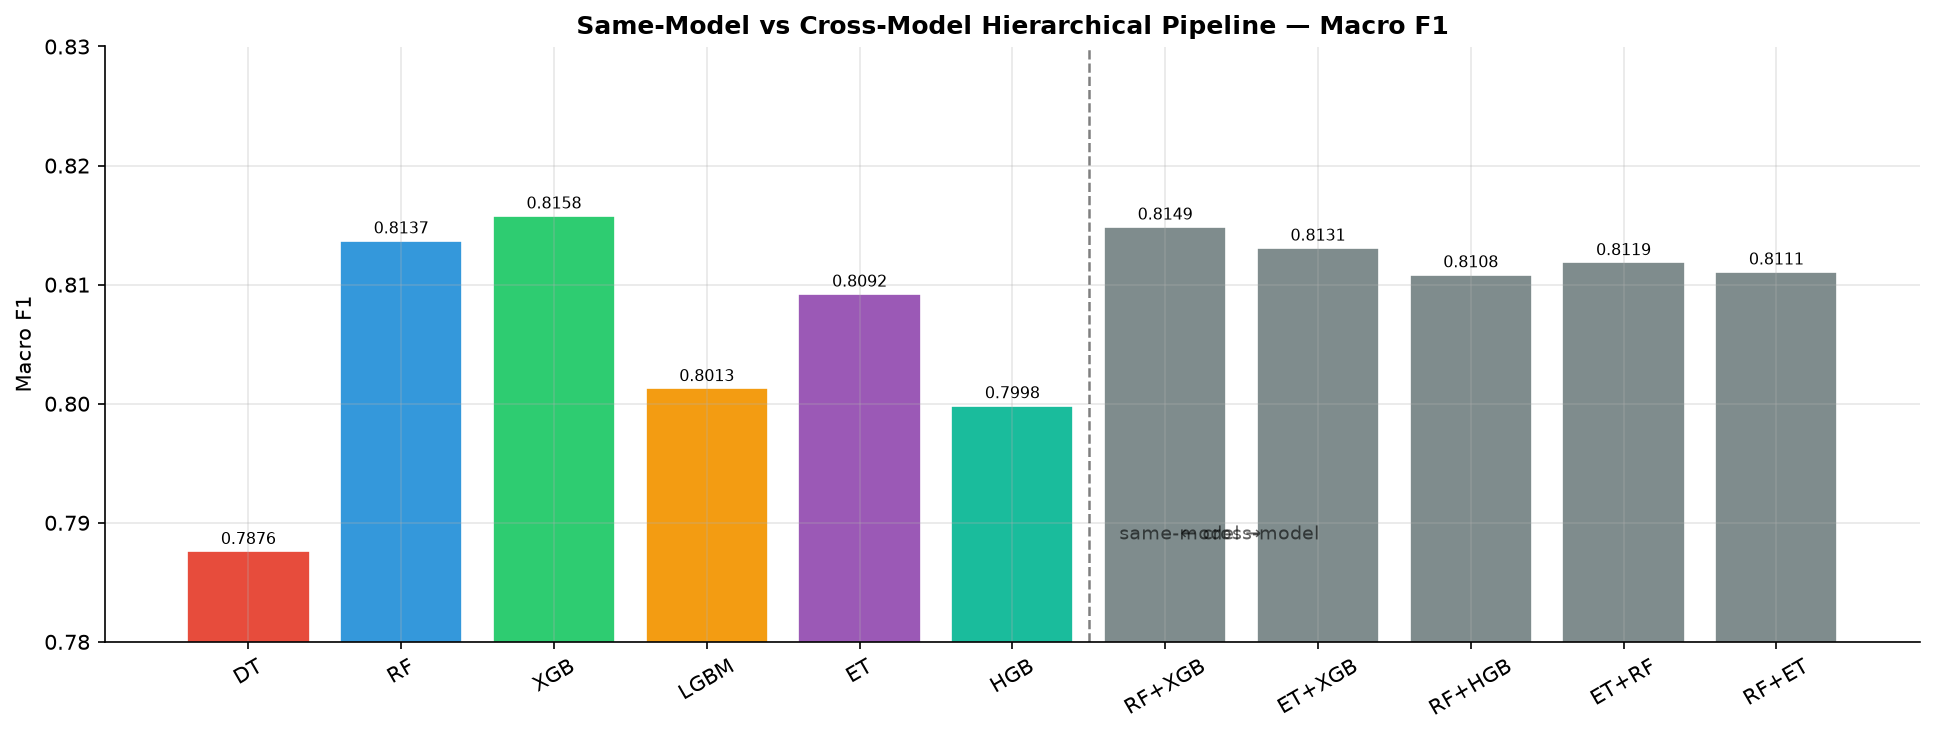

Saved: 06_cross_vs_same_model.png


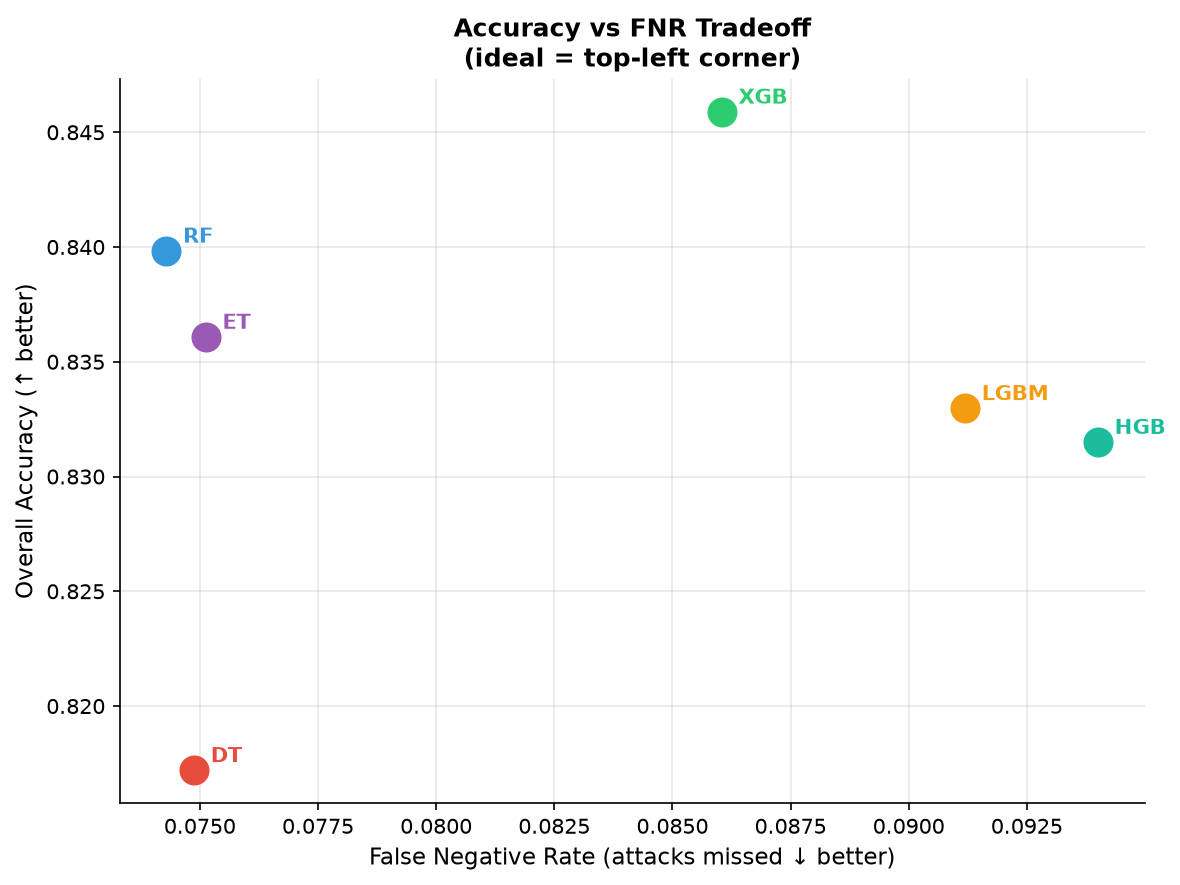

Saved: 07_accuracy_vs_fnr_tradeoff.png


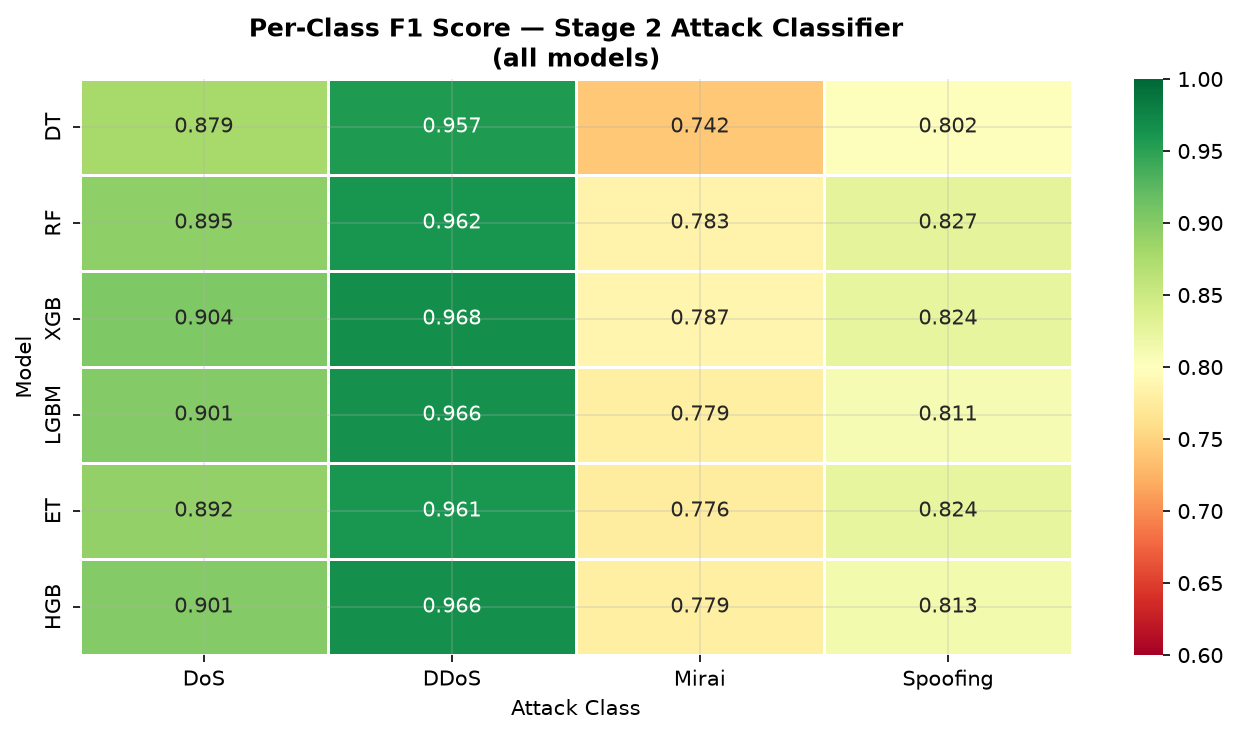

Saved: 08_perclass_f1_heatmap.png

All figures saved to ../results/figures/


In [11]:
"""
Hierarchical Pipeline — Visualizations
Saves all plots to ../results/figures/
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

os.makedirs('../results/figures', exist_ok=True)

# ── Load results ────────────────────────────────────────────────────────────
with open('../results/experiments_hierarchical.json') as f:
    results = json.load(f)

s1      = results['stage1_binary']
s2      = results['stage2_attack_type']
hier    = results['hierarchical_combined']
cross   = results['cross_model']

MODELS      = ['DT', 'RF', 'XGB', 'LGBM', 'ET', 'HGB']
LABEL_MAP   = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}
PALETTE     = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
MODEL_COLOR = dict(zip(MODELS, PALETTE))

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
})


# ══════════════════════════════════════════════════════════════════════════════
# FIG 1 — Combined pipeline comparison (Accuracy, Macro F1, FNR)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Hierarchical Pipeline — Combined Results (6 Models)', fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('accuracy',    'Accuracy',    (0.78, 0.87)),
    ('f1_macro',    'Macro F1',    (0.75, 0.83)),
    ('false_negative_rate', 'False Negative Rate (↓ better)', (0.06, 0.10)),
]

for ax, (key, label, ylim) in zip(axes, metrics):
    vals   = [hier[m][key] for m in MODELS]
    colors = [MODEL_COLOR[m] for m in MODELS]
    bars   = ax.bar(MODELS, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(ylim)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Model')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    # highlight best
    if key == 'false_negative_rate':
        best_idx = np.argmin(vals)
    else:
        best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('../results/figures/01_combined_pipeline_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 01_combined_pipeline_comparison.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 2 — Overfitting analysis (train vs test accuracy, both stages)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Analysis — Train vs Test Accuracy', fontsize=14, fontweight='bold')

for ax, (stage_data, title) in zip(axes, [
    (s1, 'Stage 1: Binary (Benign vs Attack)'),
    (s2, 'Stage 2: Attack-Type Classifier'),
]):
    train_accs = [stage_data[m]['train_accuracy'] for m in MODELS]
    test_accs  = [stage_data[m]['accuracy'] for m in MODELS]
    gaps       = [tr - te for tr, te in zip(train_accs, test_accs)]

    x = np.arange(len(MODELS))
    w = 0.35
    ax.bar(x - w/2, train_accs, w, label='Train Accuracy', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, test_accs,  w, label='Test Accuracy',  color='#e74c3c', alpha=0.8)

    for i, (tr, te, gap) in enumerate(zip(train_accs, test_accs, gaps)):
        ax.annotate('', xy=(i + w/2, te), xytext=(i - w/2, tr),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
        ax.text(i, max(tr, te) + 0.005, f'Δ{gap:.3f}',
                ha='center', fontsize=8, color='#c0392b', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylim(0.82, 1.02)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/02_overfitting_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: 02_overfitting_analysis.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 3 — Stage 1 vs Stage 2 vs Combined F1 (all models)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

s1_f1   = [s1[m]['f1']        for m in MODELS]
s2_f1   = [s2[m]['f1_macro']  for m in MODELS]
hi_f1   = [hier[m]['f1_macro'] for m in MODELS]

x = np.arange(len(MODELS))
w = 0.25
ax.bar(x - w,   s1_f1, w, label='Stage 1 F1 (Binary)',       color='#3498db', alpha=0.85)
ax.bar(x,       s2_f1, w, label='Stage 2 F1 (Attack-type)',   color='#2ecc71', alpha=0.85)
ax.bar(x + w,   hi_f1, w, label='Combined F1 (5-class macro)', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylim(0.75, 0.98)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score at Each Stage vs Combined Pipeline', fontweight='bold')
ax.legend()

for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7.5)

plt.tight_layout()
plt.savefig('../results/figures/03_stage_f1_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 03_stage_f1_comparison.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 4 — Confusion matrices (hierarchical combined, best 2 models: XGB + RF)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('5-Class Confusion Matrix — Hierarchical Combined', fontsize=14, fontweight='bold')

class_names = ['Benign', 'DoS', 'DDoS', 'Mirai', 'Spoofing']

for ax, model in zip(axes, ['XGB', 'RF']):
    cm  = np.array(hier[model]['confusion_matrix'])
    # normalize by row (true label)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=True, linewidths=0.5)
    ax.set_title(f'{model}  (Acc: {hier[model]["accuracy"]:.4f}, FNR: {hier[model]["false_negative_rate"]:.4f})',
                 fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../results/figures/04_confusion_matrices_xgb_rf.png', bbox_inches='tight')
plt.show()
print("Saved: 04_confusion_matrices_xgb_rf.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 5 — All 6 confusion matrices (normalized)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('5-Class Confusion Matrices — All Models (Normalized)', fontsize=14, fontweight='bold')

for ax, model in zip(axes.flat, MODELS):
    cm = np.array(hier[model]['confusion_matrix'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{model}  F1={hier[model]["f1_macro"]:.3f}  FNR={hier[model]["false_negative_rate"]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('../results/figures/05_all_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: 05_all_confusion_matrices.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 6 — Cross-model vs same-model comparison
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))

same_labels = MODELS
same_f1     = [hier[m]['f1_macro'] for m in MODELS]
cross_labels = [k.replace('S1=', '').replace('_S2=', '+') for k in cross.keys()]
cross_f1     = [v['f1_macro'] for v in cross.values()]

all_labels = same_labels + cross_labels
all_f1     = same_f1 + cross_f1
all_colors = PALETTE + ['#7f8c8d'] * len(cross_labels)

bars = ax.bar(all_labels, all_f1, color=all_colors, edgecolor='white', linewidth=0.8)
ax.axvline(x=len(MODELS) - 0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax.text(len(MODELS) - 0.3, min(all_f1) + 0.001, 'same-model →', fontsize=9, alpha=0.6)
ax.text(len(MODELS) + 0.1, min(all_f1) + 0.001, '← cross-model', fontsize=9, alpha=0.6)

ax.set_ylim(0.78, 0.83)
ax.set_ylabel('Macro F1')
ax.set_title('Same-Model vs Cross-Model Hierarchical Pipeline — Macro F1', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, all_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('../results/figures/06_cross_vs_same_model.png', bbox_inches='tight')
plt.show()
print("Saved: 06_cross_vs_same_model.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 7 — Accuracy vs FNR tradeoff scatter
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for m in MODELS:
    acc = hier[m]['accuracy']
    fnr = hier[m]['false_negative_rate']
    ax.scatter(fnr, acc, color=MODEL_COLOR[m], s=180, zorder=5)
    ax.annotate(m, (fnr, acc), textcoords='offset points',
                xytext=(8, 4), fontsize=10, fontweight='bold', color=MODEL_COLOR[m])

ax.set_xlabel('False Negative Rate (attacks missed ↓ better)', fontsize=11)
ax.set_ylabel('Overall Accuracy (↑ better)', fontsize=11)
ax.set_title('Accuracy vs FNR Tradeoff\n(ideal = top-left corner)', fontweight='bold')

# ideal zone annotation
ax.annotate('Ideal zone', xy=(0.073, 0.845), fontsize=9,
            color='green', alpha=0.7,
            arrowprops=dict(arrowstyle='->', color='green', alpha=0.5),
            xytext=(0.08, 0.836))

plt.tight_layout()
plt.savefig('../results/figures/07_accuracy_vs_fnr_tradeoff.png', bbox_inches='tight')
plt.show()
print("Saved: 07_accuracy_vs_fnr_tradeoff.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 8 — Per-class F1 heatmap (Stage 2, all models)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import f1_score

# Recompute per-class F1 from Stage 2 confusion matrices
attack_classes = ['DoS', 'DDoS', 'Mirai', 'Spoofing']
per_class_f1 = {}

for m in MODELS:
    cm = np.array(s2[m]['confusion_matrix'])
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)
    recall    = np.where((tp + fn) > 0, tp / (tp + fn), 0)
    f1_per    = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0)
    per_class_f1[m] = f1_per

f1_matrix = np.array([per_class_f1[m] for m in MODELS])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=attack_classes, yticklabels=MODELS,
            ax=ax, vmin=0.6, vmax=1.0, linewidths=0.5)
ax.set_title('Per-Class F1 Score — Stage 2 Attack Classifier\n(all models)', fontweight='bold')
ax.set_xlabel('Attack Class')
ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig('../results/figures/08_perclass_f1_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 08_perclass_f1_heatmap.png")


print("\nAll figures saved to ../results/figures/")

In [12]:
# ── IMPROVEMENT 1: Class Weights ─────────────────────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight

stage2_models_cw = {
    'DT':   DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1),
    'ET':   ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'HGB':  HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
}

# XGB needs sample weights passed to fit() instead
xgb_sample_weights = compute_sample_weight('balanced', y_train_attack_enc)

stage2_results_cw = {}
stage2_fitted_cw  = {}
stage2_preds_cw   = {}

for name, model in stage2_models_cw.items():
    print(f"\n--- Stage 2 (class weights): {name} ---")
    t0 = time.time()
    model.fit(X_train_attack, y_train_attack_enc)
    train_time = time.time() - t0
    stage2_fitted_cw[name] = model

    y_pred_enc = model.predict(X_test_attack)
    y_pred     = le_attack.inverse_transform(y_pred_enc)
    stage2_preds_cw[name] = y_pred

    acc  = accuracy_score(y_test_attack, y_pred)
    prec = precision_score(y_test_attack, y_pred, average='macro')
    rec  = recall_score(y_test_attack, y_pred, average='macro')
    f1   = f1_score(y_test_attack, y_pred, average='macro')
    labels_present = sorted(y_test_attack.unique())

    stage2_results_cw[name] = {
        'accuracy': acc, 'precision_macro': prec,
        'recall_macro': rec, 'f1_macro': f1
    }

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_test_attack, y_pred,
                                 target_names=[LABEL_MAP[l] for l in labels_present]))

# XGB separately
print("\n--- Stage 2 (class weights): XGB ---")
xgb_cw = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')
t0 = time.time()
xgb_cw.fit(X_train_attack, y_train_attack_enc, sample_weight=xgb_sample_weights)
train_time = time.time() - t0
stage2_fitted_cw['XGB'] = xgb_cw

y_pred_enc = xgb_cw.predict(X_test_attack)
y_pred     = le_attack.inverse_transform(y_pred_enc)
stage2_preds_cw['XGB'] = y_pred

acc  = accuracy_score(y_test_attack, y_pred)
f1   = f1_score(y_test_attack, y_pred, average='macro')
labels_present = sorted(y_test_attack.unique())
stage2_results_cw['XGB'] = {'accuracy': acc, 'f1_macro': f1}

print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
print(classification_report(y_test_attack, y_pred,
                             target_names=[LABEL_MAP[l] for l in labels_present]))


--- Stage 2 (class weights): DT ---
Accuracy: 0.8662 | Macro F1: 0.8461
              precision    recall  f1-score   support

         DoS       0.88      0.88      0.88     59940
        DDoS       0.96      0.96      0.96     59774
       Mirai       0.75      0.74      0.74     34851
    Spoofing       0.80      0.81      0.81     31390

    accuracy                           0.87    185955
   macro avg       0.85      0.85      0.85    185955
weighted avg       0.87      0.87      0.87    185955


--- Stage 2 (class weights): RF ---
Accuracy: 0.8844 | Macro F1: 0.8683
              precision    recall  f1-score   support

         DoS       0.93      0.87      0.90     59940
        DDoS       0.97      0.96      0.96     59774
       Mirai       0.75      0.82      0.79     34851
    Spoofing       0.81      0.84      0.83     31390

    accuracy                           0.88    185955
   macro avg       0.86      0.87      0.87    185955
weighted avg       0.89      0.88      

In [13]:
# Combined pipeline with class-weighted Stage 2
hierarchical_results_cw = {}
hierarchical_preds_cw   = {}

for name in stage2_fitted_cw.keys():
    print(f"\n=== Hierarchical CW: {name} ===")

    stage1_pred  = stage1_preds[name]   # reuse original Stage 1 predictions
    stage2_model = stage2_fitted_cw[name]

    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(stage1_pred == 'Benign')[0]
    attack_idx = np.where(stage1_pred == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_pred_enc = stage2_model.predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_pred_enc)

    final_pred = final_pred.astype(int)
    hierarchical_preds_cw[name] = final_pred
    y_test_arr = y_test.values
    all_labels = sorted(LABEL_MAP.keys())

    acc         = accuracy_score(y_test_arr, final_pred)
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    hierarchical_results_cw[name] = {
        'accuracy': acc, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'false_negative_rate': fnr
    }

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f} | FNR: {fnr:.4f}")
    print(classification_report(y_test_arr, final_pred,
                                 target_names=[LABEL_MAP[l] for l in all_labels]))


=== Hierarchical CW: DT ===
Accuracy: 0.8175 | Macro F1: 0.7882 | FNR: 0.0749
              precision    recall  f1-score   support

      Benign       0.82      0.82      0.82     79574
         DoS       0.85      0.86      0.86     59940
        DDoS       0.96      0.95      0.95     59774
       Mirai       0.68      0.68      0.68     34851
    Spoofing       0.63      0.64      0.63     31390

    accuracy                           0.82    265529
   macro avg       0.79      0.79      0.79    265529
weighted avg       0.82      0.82      0.82    265529


=== Hierarchical CW: RF ===
Accuracy: 0.8406 | Macro F1: 0.8150 | FNR: 0.0743
              precision    recall  f1-score   support

      Benign       0.83      0.86      0.84     79574
         DoS       0.91      0.85      0.88     59940
        DDoS       0.97      0.95      0.96     59774
       Mirai       0.69      0.77      0.73     34851
    Spoofing       0.67      0.65      0.66     31390

    accuracy               

In [14]:
# Before vs after comparison
print(f"{'Model':<8} {'Before F1':>10} {'After F1':>10} {'Change':>8}")
print("-" * 40)
for name in MODELS:
    before = hierarchical_results[name]['f1_macro']
    after  = hierarchical_results_cw.get(name, {}).get('f1_macro', 0)
    change = after - before
    arrow  = '↑' if change > 0 else '↓'
    print(f"{name:<8} {before:>10.4f} {after:>10.4f}  {arrow}{abs(change):.4f}")

Model     Before F1   After F1   Change
----------------------------------------
DT           0.7876     0.7882  ↑0.0006
RF           0.8137     0.8150  ↑0.0013
XGB          0.8158     0.8164  ↑0.0006
LGBM         0.8013     0.8021  ↑0.0008
ET           0.8092     0.8093  ↑0.0001
HGB          0.7998     0.8019  ↑0.0020


In [15]:
# ── IMPROVEMENT 2: Stage 1 Threshold Tuning ──────────────────────────────────

# Get attack probabilities from RF Stage 1 (best FNR model)
attack_class_idx = list(le_binary.classes_).index('Attack')
rf_proba = stage1_fitted['RF'].predict_proba(X_test)[:, attack_class_idx]

print(f"{'Threshold':>10} {'FNR':>8} {'Accuracy':>10} {'F1':>8} {'FP Rate':>10}")
print("-" * 50)

threshold_results = {}
thresholds = np.arange(0.30, 0.60, 0.02)

for thresh in thresholds:
    y_pred_thresh = np.where(rf_proba >= thresh, 'Attack', 'Benign')
    
    fnr = np.sum((y_test_binary == 'Attack') & (y_pred_thresh == 'Benign')) / np.sum(y_test_binary == 'Attack')
    fpr = np.sum((y_test_binary == 'Benign') & (y_pred_thresh == 'Attack')) / np.sum(y_test_binary == 'Benign')
    acc = accuracy_score(y_test_binary, y_pred_thresh)
    f1  = f1_score(y_test_binary, y_pred_thresh, pos_label='Attack')
    
    threshold_results[round(thresh, 2)] = {
        'fnr': fnr, 'accuracy': acc, 'f1': f1, 'fpr': fpr
    }
    print(f"{thresh:>10.2f} {fnr:>8.4f} {acc:>10.4f} {f1:>8.4f} {fpr:>10.4f}")

 Threshold      FNR   Accuracy       F1    FP Rate
--------------------------------------------------
      0.30   0.0526     0.8972   0.9281     0.2203
      0.32   0.0554     0.8991   0.9292     0.2070
      0.34   0.0584     0.9004   0.9298     0.1960
      0.36   0.0624     0.9019   0.9305     0.1814
      0.38   0.0649     0.9027   0.9309     0.1729
      0.40   0.0671     0.9035   0.9312     0.1653
      0.42   0.0688     0.9040   0.9315     0.1594
      0.44   0.0705     0.9044   0.9316     0.1542
      0.46   0.0720     0.9047   0.9317     0.1499
      0.48   0.0735     0.9049   0.9317     0.1456
      0.50   0.0750     0.9049   0.9316     0.1421
      0.52   0.0762     0.9050   0.9316     0.1388
      0.54   0.0784     0.9052   0.9316     0.1331
      0.56   0.0805     0.9052   0.9315     0.1281
      0.58   0.0824     0.9054   0.9314     0.1231


In [16]:
# ── Threshold tuning — full combined pipeline ─────────────────────────────────

best_thresholds = {'balanced': 0.44, 'security': 0.30}

threshold_pipeline_results = {}

for label, thresh in best_thresholds.items():
    print(f"\n=== RF Stage 1 (threshold={thresh}) + RF Stage 2 CW ===")

    # Stage 1 predictions at custom threshold
    y_pred_s1 = np.where(rf_proba >= thresh, 'Attack', 'Benign')

    # Combined pipeline
    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(y_pred_s1 == 'Benign')[0]
    attack_idx = np.where(y_pred_s1 == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_pred_enc = stage2_fitted_cw['RF'].predict_proba(X_test.iloc[attack_idx])
        s2_pred_enc = stage2_fitted_cw['RF'].predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_pred_enc)

    final_pred = final_pred.astype(int)
    y_test_arr = y_test.values
    all_labels = sorted(LABEL_MAP.keys())

    acc         = accuracy_score(y_test_arr, final_pred)
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    threshold_pipeline_results[label] = {
        'threshold': thresh, 'accuracy': acc,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'false_negative_rate': fnr
    }

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f} | FNR: {fnr:.4f}")
    print(classification_report(y_test_arr, final_pred,
                                 target_names=[LABEL_MAP[l] for l in all_labels]))

# Compare against original RF baseline
print("\n── Summary ──────────────────────────────────────────────────")
print(f"{'Setup':<30} {'Accuracy':>10} {'Macro F1':>10} {'FNR':>8}")
print("-" * 62)
print(f"{'RF original (thresh=0.50)':<30} "
      f"{hierarchical_results['RF']['accuracy']:>10.4f} "
      f"{hierarchical_results['RF']['f1_macro']:>10.4f} "
      f"{hierarchical_results['RF']['false_negative_rate']:>8.4f}")
for label, r in threshold_pipeline_results.items():
    print(f"{'RF '+label+' (thresh='+str(r['threshold'])+')':<30} "
          f"{r['accuracy']:>10.4f} "
          f"{r['f1_macro']:>10.4f} "
          f"{r['false_negative_rate']:>8.4f}")


=== RF Stage 1 (threshold=0.44) + RF Stage 2 CW ===
Accuracy: 0.8389 | Macro F1: 0.8140 | FNR: 0.0698
              precision    recall  f1-score   support

      Benign       0.84      0.84      0.84     79574
         DoS       0.91      0.85      0.88     59940
        DDoS       0.97      0.95      0.96     59774
       Mirai       0.69      0.77      0.73     34851
    Spoofing       0.66      0.67      0.66     31390

    accuracy                           0.84    265529
   macro avg       0.81      0.82      0.81    265529
weighted avg       0.84      0.84      0.84    265529


=== RF Stage 1 (threshold=0.3) + RF Stage 2 CW ===
Accuracy: 0.8280 | Macro F1: 0.8061 | FNR: 0.0526
              precision    recall  f1-score   support

      Benign       0.86      0.78      0.82     79574
         DoS       0.90      0.85      0.87     59940
        DDoS       0.97      0.95      0.96     59774
       Mirai       0.67      0.79      0.72     34851
    Spoofing       0.60      0.71  

In [17]:
# ── IMPROVEMENT 3: Separate ANOVA Feature Selection Per Stage ─────────────────
from sklearn.feature_selection import SelectKBest, f_classif

# Stage 1 — feature selection on binary problem (Benign vs Attack)
selector_s1 = SelectKBest(f_classif, k=30)
X_train_s1  = selector_s1.fit_transform(X_train, y_train_binary_enc)
X_test_s1   = selector_s1.transform(X_test)

# Stage 2 — feature selection on attack-only rows
selector_s2 = SelectKBest(f_classif, k=30)
X_train_s2  = selector_s2.fit_transform(X_train_attack, y_train_attack_enc)
X_test_s2   = selector_s2.transform(X_test_attack)

# How different are the two feature sets?
s1_features   = set(selector_s1.get_support(indices=True))
s2_features   = set(selector_s2.get_support(indices=True))
shared        = s1_features & s2_features
unique_to_s1  = s1_features - s2_features
unique_to_s2  = s2_features - s1_features

feature_names = X_train.columns.tolist()

print(f"Features shared between Stage 1 and Stage 2: {len(shared)}/30")
print(f"Features unique to Stage 1: {len(unique_to_s1)} → {[feature_names[i] for i in unique_to_s1]}")
print(f"Features unique to Stage 2: {len(unique_to_s2)} → {[feature_names[i] for i in unique_to_s2]}")

Features shared between Stage 1 and Stage 2: 30/30
Features unique to Stage 1: 0 → []
Features unique to Stage 2: 0 → []


In [18]:
import joblib
import os

os.makedirs('../results/models', exist_ok=True)

for name, model in stage1_fitted.items():
    joblib.dump(model, f'../results/models/hier_stage1_{name}.pkl')
    print(f"Saved: hier_stage1_{name}.pkl")

for name, model in stage2_fitted.items():
    joblib.dump(model, f'../results/models/hier_stage2_{name}.pkl')
    print(f"Saved: hier_stage2_{name}.pkl")

Saved: hier_stage1_DT.pkl
Saved: hier_stage1_RF.pkl
Saved: hier_stage1_XGB.pkl
Saved: hier_stage1_LGBM.pkl
Saved: hier_stage1_ET.pkl
Saved: hier_stage1_HGB.pkl
Saved: hier_stage2_DT.pkl
Saved: hier_stage2_RF.pkl
Saved: hier_stage2_XGB.pkl
Saved: hier_stage2_LGBM.pkl
Saved: hier_stage2_ET.pkl
Saved: hier_stage2_HGB.pkl
